# HRV COVID-19 Data Exploration

In [36]:
import pandas as pd
from pathlib import Path


In [37]:
data_dir = Path('hrv-covid19/data')

participants = pd.read_csv(data_dir / 'participants.csv')
hrv_measurements = pd.read_csv(data_dir / 'hrv_measurements.csv')
heart_rate = pd.read_csv(data_dir / 'heart_rate.csv')
sleep = pd.read_csv(data_dir / 'sleep.csv')
surveys = pd.read_csv(data_dir / 'surveys.csv')
wearables = pd.read_csv(data_dir / 'wearables.csv')
blood_pressure = pd.read_csv(data_dir / 'blood_pressure.csv')
weather = pd.read_csv(data_dir / 'weather.csv')
scales_description = pd.read_csv(data_dir / 'scales_description.csv')


In [38]:
# Collect all tables in a single dictionary so checks can iterate uniformly.
datasets = {
    'participants': participants,
    'hrv_measurements': hrv_measurements,
    'heart_rate': heart_rate,
    'sleep': sleep,
    'surveys': surveys,
    'wearables': wearables,
    'blood_pressure': blood_pressure,
    'weather': weather,
    'scales_description': scales_description,
}


In [39]:
# Inspect dataset shapes and column samples to understand schema before deeper analysis.
for name, df in datasets.items():
    print(f'{name}: {df.shape}')
    print('Columns:', list(df.columns)[:8])
    print('-' * 40)


participants: (185, 8)
Columns: ['user_code', 'gender', 'age_range', 'city', 'country', 'height', 'weight', 'symptoms_onset']
----------------------------------------
hrv_measurements: (3245, 22)
Columns: ['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'bpm', 'meanrr', 'mxdmn', 'sdnn']
----------------------------------------
heart_rate: (523783, 4)
Columns: ['user_code', 'datetime', 'heart_rate', 'is_resting']
----------------------------------------
sleep: (425, 12)
Columns: ['user_code', 'day', 'sleep_begin', 'sleep_end', 'sleep_duration', 'sleep_awake_duration', 'sleep_rem_duration', 'sleep_light_duration']
----------------------------------------
surveys: (2259, 5)
Columns: ['user_code', 'scale', 'created_at', 'value', 'text']
----------------------------------------
wearables: (3098, 18)
Columns: ['user_code', 'day', 'resting_pulse', 'pulse_average', 'pulse_min', 'pulse_max', 'average_spo2_value', 'body_temperature_avg']
----------------------------------------
bl

There were a lot of missing values in the wearables/blood pressure/heart-rate/sleep tables, so I checked how many participants actually had logs. Only 79 people had the per-second heart-rate/wearables feed recorded, only 28 appeared in the blood pressue logs and only 10 provided sleep sessions, which is why I chose not to use those tables for the initial analysis. I also avoided the scales_description and surveys data as it was text and likely not something I could readily clean and apply quickly, and also only 111 of participants had survey data. Additionally, I did not think weather would be relevant for the simple analysis I wanted to perform for this assignment. I still ran the basic cleaning steps so the data would be ready if I revisit them later, even though they do not appear in the final visualizations.

In [40]:
# Return number of users accounted for in heart-rate, wearables, and sleep streamed data.
participants_count = participants['user_code'].nunique()
heart_rate_users = heart_rate['user_code'].nunique()
blood_pressure_users = blood_pressure['user_code'].nunique()
sleep_users = sleep['user_code'].nunique()
wearables_users = wearables['user_code'].nunique()
surveys_users = surveys['user_code'].nunique()
print(f'Total participants: {participants_count}')
print(f'Heart-rate users: {heart_rate_users}')
print(f'Blood pressure users: {blood_pressure_users}')
print(f'Sleep log users: {sleep_users}')
print(f'Wearables users: {wearables_users}')
print(f'Survey users: {surveys_users}')


Total participants: 185
Heart-rate users: 79
Blood pressure users: 28
Sleep log users: 10
Wearables users: 79
Survey users: 111


Moving forward I decided to mainly focus on participants and hrv_measurements.

In [41]:
# Generate descriptive statistics to capture central tendency and spread for key numeric fields.
participants_height = pd.to_numeric(participants['height'], errors='coerce')
participants_weight = pd.to_numeric(participants['weight'], errors='coerce')
hrv_bpm = hrv_measurements['bpm']
hrv_sdnn = hrv_measurements['sdnn']
print('Participants height stats:', participants_height.describe())
print('Participants weight stats:', participants_weight.describe())
print('HRV bpm stats:', hrv_bpm.describe())
print('HRV SDNN stats:', hrv_sdnn.describe())


Participants height stats: count    183.000000
mean     169.976393
std       12.400103
min      132.080000
25%      163.500000
50%      168.000000
75%      174.500000
max      250.000000
Name: height, dtype: float64
Participants weight stats: count    185.000000
mean      77.927757
std       19.552541
min       43.500000
25%       63.500000
50%       74.344000
75%       90.537000
max      154.221000
Name: weight, dtype: float64
HRV bpm stats: count    3245.000000
mean       73.257935
std        12.201088
min        44.000000
25%        65.000000
50%        72.000000
75%        81.000000
max       125.000000
Name: bpm, dtype: float64
HRV SDNN stats: count    3245.000000
mean       52.489218
std        29.369506
min         9.515000
25%        32.585000
50%        46.919000
75%        64.406000
max       206.631000
Name: sdnn, dtype: float64


For relationships I focused on the HRV fields because those were already clean enough to compare and most relevant to the analysis I wanted to pursue.

In [42]:
# Examine correlations among HRV metrics to understand physiological relationships between variables.
hrv_metrics = hrv_measurements[['bpm', 'meanrr', 'sdnn', 'rmssd', 'lf', 'hf', 'vlf', 'total_power', 'lfhf']]
correlation_matrix = hrv_metrics.corr()
correlation_matrix


,bpm,meanrr,sdnn,rmssd,lf,hf,vlf,total_power,lfhf
bpm,1.000000,-0.977724,-0.341514,-0.214339,-0.171505,-0.105204,-0.240630,-0.184698,-0.003373
meanrr,-0.977724,1.000000,0.348052,0.231696,0.176511,0.128630,0.242066,0.201795,-0.024851
sdnn,-0.341514,0.348052,1.000000,0.909046,0.743380,0.773958,0.489891,0.879030,-0.022080
rmssd,-0.214339,0.231696,0.909046,1.000000,0.629966,0.857374,0.274702,0.841720,-0.164167
lf,-0.171505,0.176511,0.743380,0.629966,1.000000,0.601294,0.338897,0.830744,0.163171
hf,-0.105204,0.128630,0.773958,0.857374,0.601294,1.000000,0.227192,0.911203,-0.123659
vlf,-0.240630,0.242066,0.489891,0.274702,0.338897,0.227192,1.000000,0.494792,0.021866
total_power,-0.184698,0.201795,0.879030,0.841720,0.830744,0.911203,0.494792,1.000000,-0.013119
lfhf,-0.003373,-0.024851,-0.022080,-0.164167,0.163171,-0.123659,0.021866,-0.013119,1.000000


For missing values I cleaned up the obvious points by making heights and weights numeric and filling gaps with gender medians so BMI math is possible.

In [43]:
participants_filled = participants.copy()
participants_filled['height'] = pd.to_numeric(participants_filled['height'], errors='coerce')
participants_filled['weight'] = pd.to_numeric(participants_filled['weight'], errors='coerce')
gender_medians = participants_filled.groupby('gender')['height'].transform('median')
participants_filled['height'] = participants_filled['height'].fillna(gender_medians)
participants_filled['height'] = participants_filled['height'].fillna(participants_filled['height'].median())
print('Filled height nulls:', participants['height'].isna().sum())
print('Filled weight nulls:', participants['weight'].isna().sum())


Filled height nulls: 2
Filled weight nulls: 0


In [44]:
# Dedupe all tables at once
deduped_tables = {}
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    deduped_tables[name] = df.drop_duplicates()
    print(f'{name}: {dup_count} duplicate rows removed')


participants: 0 duplicate rows removed
hrv_measurements: 0 duplicate rows removed
heart_rate: 0 duplicate rows removed
sleep: 0 duplicate rows removed
surveys: 0 duplicate rows removed
wearables: 0 duplicate rows removed
blood_pressure: 0 duplicate rows removed
weather: 0 duplicate rows removed
scales_description: 0 duplicate rows removed


I clipped outliers instead of tossing them so extreme heights or weights wouldn't influence averages.

In [45]:
# Clean outliers in participants.csv
participants_capped = participants_filled.copy()
for col in ['height', 'weight']:
    series = participants_capped[col]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    participants_capped[col] = series.clip(lower=lower, upper=upper)
    print(f'{col} outlier bounds: {lower:.1f} to {upper:.1f}')
print('Pre-capping height range:', participants_filled['height'].min(), participants_filled['height'].max())
print('Pre-capping weight range:', participants_filled['weight'].min(), participants_filled['weight'].max())
print('Post-capping height range:', participants_capped['height'].min(), participants_capped['height'].max())
print('Post-capping weight range:', participants_capped['weight'].min(), participants_capped['weight'].max())


height outlier bounds: 147.5 to 191.5
weight outlier bounds: 22.9 to 131.1
Pre-capping height range: 132.08 250.0
Pre-capping weight range: 43.5 154.221
Post-capping height range: 147.5 191.5
Post-capping weight range: 43.5 131.09250000000003


Below I applied more targeted cleaning for the remaining tables just in case I wanted to use them later.

In [46]:
# Blood pressure: cast to numeric, parse timestamps, and clip implausible values.
blood_pressure_clean = blood_pressure.copy()
blood_pressure_clean['measurement_datetime'] = pd.to_datetime(blood_pressure_clean['measurement_datetime'])
for col in ['systolic', 'diastolic', 'functional_changes_index', 'circulatory_efficiency', 'kerdo_vegetation_index', 'robinson_index']:
    blood_pressure_clean[col] = pd.to_numeric(blood_pressure_clean[col], errors='coerce')
blood_pressure_clean['systolic'] = blood_pressure_clean['systolic'].clip(lower=80, upper=220)
blood_pressure_clean['diastolic'] = blood_pressure_clean['diastolic'].clip(lower=40, upper=140)
blood_pressure_clean = blood_pressure_clean.drop_duplicates()

# Heart rate: enforce numeric range and boolean resting flag.
heart_rate_clean = heart_rate.copy()
heart_rate_clean['datetime'] = pd.to_datetime(heart_rate_clean['datetime'])
heart_rate_clean['heart_rate'] = pd.to_numeric(heart_rate_clean['heart_rate'], errors='coerce')
heart_rate_clean = heart_rate_clean[(heart_rate_clean['heart_rate'] >= 30) & (heart_rate_clean['heart_rate'] <= 220)]
heart_rate_clean['is_resting'] = heart_rate_clean['is_resting'].astype(bool)

# Sleep: parse timestamps, convert durations to hours, and null out negatives.
sleep_clean = sleep.copy()
sleep_clean['sleep_begin'] = pd.to_datetime(sleep_clean['sleep_begin'])
sleep_clean['sleep_end'] = pd.to_datetime(sleep_clean['sleep_end'])
duration_cols = ['sleep_duration', 'sleep_awake_duration', 'sleep_rem_duration', 'sleep_light_duration', 'sleep_deep_duration']
for col in duration_cols:
    sleep_clean[col] = pd.to_numeric(sleep_clean[col], errors='coerce')
    sleep_clean.loc[sleep_clean[col] < 0, col] = pd.NA
sleep_clean['sleep_hours'] = sleep_clean['sleep_duration'] / 3600

# Wearables: drop highly missing columns (already tracked above) and coerce numeric readings.
wearables_clean = wearables.copy()
wearables_clean['day'] = pd.to_datetime(wearables_clean['day'])
numeric_cols = wearables_clean.columns.difference(['user_code', 'day'])
for col in numeric_cols:
    wearables_clean[col] = pd.to_numeric(wearables_clean[col], errors='coerce')
    wearables_clean.loc[wearables_clean[col] < 0, col] = pd.NA

# Surveys: trim text to keep responses tidy.
surveys_clean = surveys.copy()
surveys_clean['scale'] = surveys_clean['scale'].str.strip()
surveys_clean['text'] = surveys_clean['text'].fillna('').str.strip()

# Weather: parse day and convert metrics to numeric to prepare for joins.
weather_clean = weather.copy()
weather_clean['day'] = pd.to_datetime(weather_clean['day'])
weather_metrics = weather_clean.columns.difference(['user_code', 'day'])
for col in weather_metrics:
    weather_clean[col] = pd.to_numeric(weather_clean[col], errors='coerce')

BMI is a relevant derived feature since it ties body composition to the HRV story, so I calculated it off the cleaned height/weight values.

In [47]:
participants_features = participants_capped.copy()
participants_features['height_m'] = participants_features['height'] / 100
participants_features['bmi'] = participants_features['weight'] / (participants_features['height_m'] ** 2)
print(participants_features[['user_code', 'height', 'weight', 'bmi']].head())


    user_code  height  weight        bmi
0  007b8190cf  170.18  96.162  33.203698
1  013f6d3e5b  174.00  77.300  25.531774
2  01bad5a519  178.00  92.000  29.036738
3  0210b20eea  169.00  60.000  21.007668
4  024719e7da  158.00  68.500  27.439513


## Visualizations

SDNN is the HRV stat for overall variability, so I plotted its distribution to see the spread and whether there was a long tail of high-variability readings.

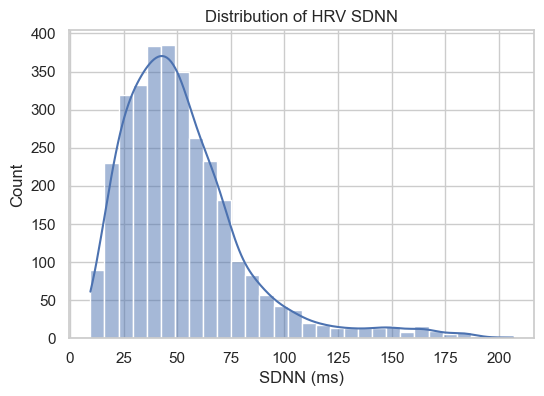

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.figure(figsize=(6, 4))
sns.histplot(hrv_measurements['sdnn'], bins=30, kde=True)
plt.title('Distribution of HRV SDNN')
plt.xlabel('SDNN (ms)')
plt.ylabel('Count')
plt.show()


The SDNN distribution shows most readings between ~20–80 ms with a right tail, which lines up with a mix of normal variability and occasional high-variability sessions.

Time of day can shift HRV, so this boxplot checked whether RMSSD trended higher at certain times.

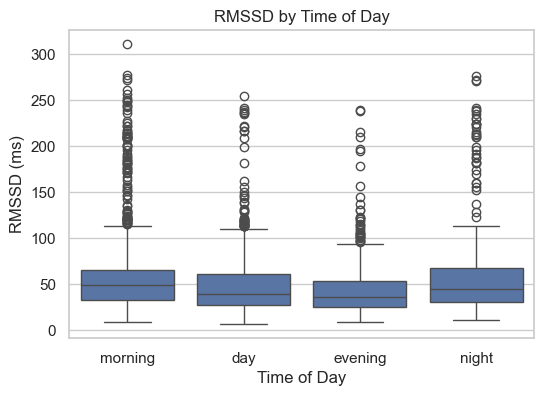

In [49]:
plt.figure(figsize=(6, 4))
order = ['morning', 'day', 'evening', 'night']
sns.boxplot(data=hrv_measurements, x='time_of_day', y='rmssd', order=order)
plt.title('RMSSD by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('RMSSD (ms)')
plt.show()


RMSSD tended to run a touch higher in the morning/night boxes, which suggests that individuals were more relaxed before and after sleep rather than through the day.

BMI gave me a quick read on how many individuals sat in higher-risk categories.

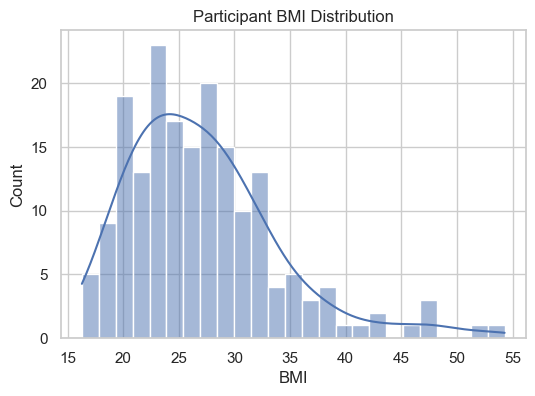

In [50]:
plt.figure(figsize=(6, 4))
sns.histplot(participants_features['bmi'], bins=25, kde=True)
plt.title('Participant BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()


BMI skewed toward the mid-to-upper 20s, with a sizable group above 30.

To see whether body composition relates to HRV recovery, I paired each RMSSD reading with the participant's BMI and bucketed BMI into quartiles.

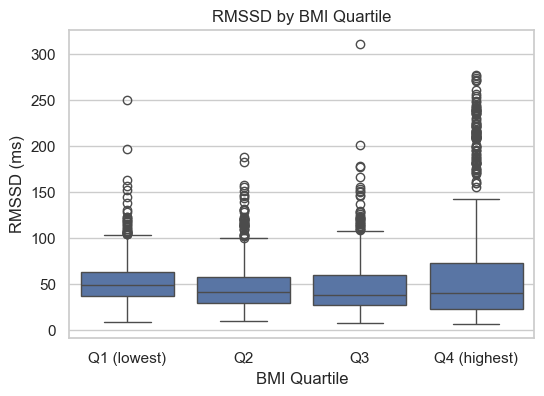

In [51]:
hrv_with_bmi = hrv_measurements.merge(participants_features[['user_code', 'bmi']], on='user_code', how='left')
hrv_with_bmi = hrv_with_bmi.dropna(subset=['bmi', 'rmssd'])
hrv_with_bmi['bmi_quartile'] = pd.qcut(hrv_with_bmi['bmi'], 4, labels=['Q1 (lowest)','Q2','Q3','Q4 (highest)'])
plt.figure(figsize=(6, 4))
sns.boxplot(data=hrv_with_bmi, x='bmi_quartile', y='rmssd')
plt.title('RMSSD by BMI Quartile')
plt.xlabel('BMI Quartile')
plt.ylabel('RMSSD (ms)')
plt.show()


RMSSD dropped a little in the higher BMI quartiles, hinting at a less restful nervous system among heavier users, but the boxes still overlap a lot so the trend isn't decisive.

## Data Quality Assessment

**Completeness.** Participant and hrv data is primarily whole, though any data relating to sensor feeds are sparse (ie. blood pressure/heart-rate/sleep data). Analyses that depend on those tables need to tolerate large gaps or restrict to those users. Additionally, only 111 users were accounted for in the survey data, leading to potentially similar problems if conducting text analysis.

**Accuracy.** Signals come from consumer devices and self-reporting, so measurement error and user-entry mistakes should be expected. Height and weight values generally fall into plausible ranges, but outliers do appear. Timestamp formats are consistent ISO strings, though the lack of timezone metadata means local time interpretation is uncertain.

**Consistency.** Keys line up across files: `user_code` ties participants to all measurement tables, and day or timestamp fields follow a uniform style. Time-of-day labels in the HRV file use the same vocabulary (morning, day, evening, night) throughout. Text columns such as survey scales match the definitions documented in `scales_description.csv`.

**Integrity.** The release does not include duplicate `user_code` entries and every measurement record references a participant in the demographics table. Each table ships with its own unique identifier (`rr_code`, timestamps, or day fields) that can serve as a primary key.

**Lineage and provenance.** All data originate from the Welltory COVID-19 research program and is distributed under a Creative Commons license in the `hrv-covid19` repository. The files were exported directly from the project’s data pipeline, so any subsequent cleaning or feature engineering should be documented as such.